## I. Importing essential libraries

In [15]:
import numpy as np
import pandas as pd # data handling
import matplotlib.pyplot as plt # for graphs 
import seaborn as sns  # for data visualization

%matplotlib inline

import os # view directory
print(os.listdir())

import warnings #ignores warning 
warnings.filterwarnings('ignore')

['heart.csv', 'model.pkl', 'README.md', 'Heart_disease_prediction.ipynb', 'output.png', '.venv', '.ipynb_checkpoints', 'Screenshot 2025-11-20 at 2.22.37\u202fPM.png', '.git', '.idea']


## II. Importing and understanding our dataset 

In [16]:
dataset = pd.read_csv("heart.csv")

#### Verifying it as a 'dataframe' object in pandas

In [17]:
type(dataset)

pandas.DataFrame

#### Shape of dataset

In [18]:
dataset.shape # no of row columns

(303, 14)

#### Printing out a few columns

In [19]:
dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [20]:
dataset.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
187,54,1,0,124,266,0,0,109,1,2.2,1,1,3,0
41,48,1,1,130,245,0,0,180,0,0.2,1,0,2,1
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2,0
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
34,51,1,3,125,213,0,0,125,1,1.4,2,1,2,1


#### Description

In [21]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [22]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [23]:
## no missing values

#### Let's understand our columns better:  ##medical attributes

In [24]:
info = ["age","1: male, 0: female","chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic","resting blood pressure"," serum cholestoral in mg/dl","fasting blood sugar > 120 mg/dl","resting electrocardiographic results (values 0,1,2)"," maximum heart rate achieved","exercise induced angina","oldpeak = ST depression induced by exercise relative to rest","the slope of the peak exercise ST segment","number of major vessels (0-3) colored by flourosopy","thal: 3 = normal; 6 = fixed defect; 7 = reversable defect"]



for i in range(len(info)):
    print(dataset.columns[i]+":\t\t\t"+info[i])

age:			age
sex:			1: male, 0: female
cp:			chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic
trestbps:			resting blood pressure
chol:			 serum cholestoral in mg/dl
fbs:			fasting blood sugar > 120 mg/dl
restecg:			resting electrocardiographic results (values 0,1,2)
thalach:			 maximum heart rate achieved
exang:			exercise induced angina
oldpeak:			oldpeak = ST depression induced by exercise relative to rest
slope:			the slope of the peak exercise ST segment
ca:			number of major vessels (0-3) colored by flourosopy
thal:			thal: 3 = normal; 6 = fixed defect; 7 = reversable defect


#### Analysing the 'target' variable

In [25]:
dataset["target"].describe() ## target values it checks the output ie o or 1 #decribe target column

count    303.000000
mean       0.544554
std        0.498835
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64

In [26]:
dataset["target"].unique() # give unique value of output 

array([1, 0])

#### Clearly, this is a classification problem, with the target variable having values '0' and '1'

### Checking correlation between columns

In [27]:
print(dataset.corr()["target"].abs().sort_values(ascending=False))

target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


In [28]:
#This shows that most columns are moderately correlated with target, but 'fbs' is very weakly correlated.

## Exploratory Data Analysis (EDA) ## only for visualization ie better understanding for data attributes

### First, analysing the target variable:

target
1    165
0    138
Name: count, dtype: int64


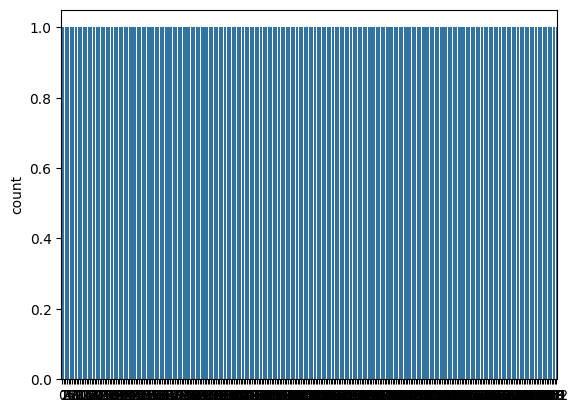

In [29]:
y = dataset["target"]

sns.countplot(y)


target_temp = dataset.target.value_counts()

print(target_temp)

In [30]:
print("Percentage of patience without heart problems: "+str(round(target_temp[0]*100/303,2)))
print("Percentage of patience with heart problems: "+str(round(target_temp[1]*100/303,2)))

#Alternatively,
# print("Percentage of patience with heart problems: "+str(y.where(y==1).count()*100/303))
# print("Percentage of patience with heart problems: "+str(y.where(y==0).count()*100/303))

# #Or,
# countNoDisease = len(df[df.target == 0])
# countHaveDisease = len(df[df.target == 1])

Percentage of patience without heart problems: 45.54
Percentage of patience with heart problems: 54.46


### We'll analyse 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca' and 'thal' features

### Analysing the 'Sex' feature

In [31]:
dataset["sex"].unique()

array([1, 0])

##### We notice, that as expected, the 'sex' feature has 2 unique features

<Axes: xlabel='sex', ylabel='target'>

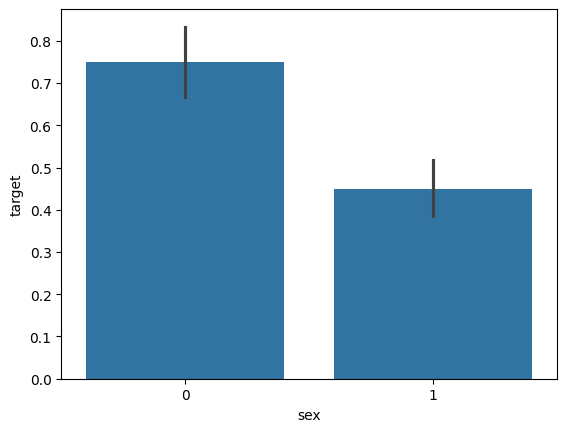

In [32]:
sns.barplot(x=dataset["sex"], y=y)


##### We notice, that females are more likely to have heart problems than males

### Analysing the 'Chest Pain Type' feature

In [33]:
dataset["cp"].unique()

array([3, 2, 1, 0])

##### As expected, the CP feature has values from 0 to 3

<Axes: xlabel='cp', ylabel='target'>

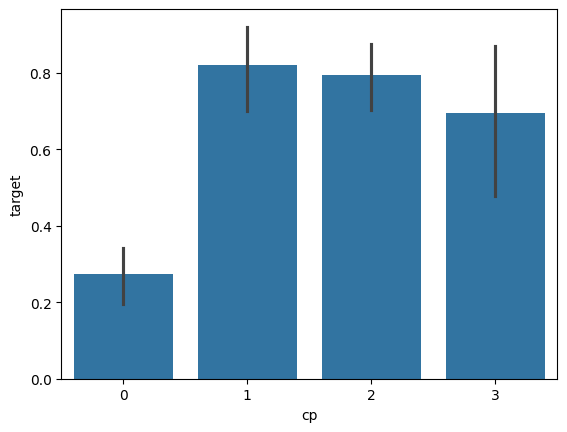

In [34]:
sns.barplot(x=dataset["cp"], y=y)


##### We notice, that chest pain of '0', i.e. the ones with typical angina are much less likely to have heart problems

### Analysing the FBS feature

In [35]:
dataset["fbs"].describe()

count    303.000000
mean       0.148515
std        0.356198
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: fbs, dtype: float64

In [36]:
dataset["fbs"].unique() # blood sugar 

array([1, 0])

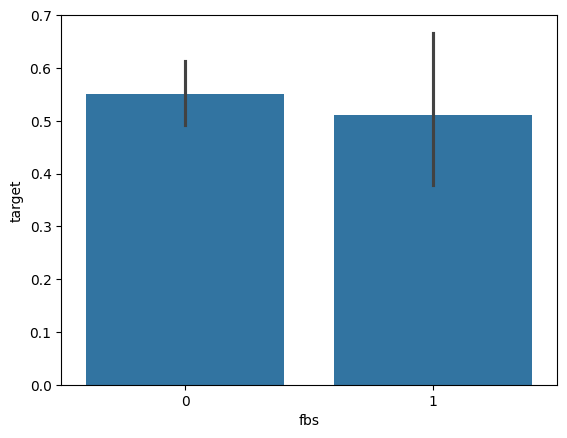

In [37]:
sns.barplot(x=dataset["fbs"], y=y)
plt.show()


##### Nothing extraordinary here  1 means high 0 normal

### Analysing the restecg feature

In [38]:
dataset["restecg"].unique()

array([0, 1, 2])

<Axes: xlabel='restecg', ylabel='target'>

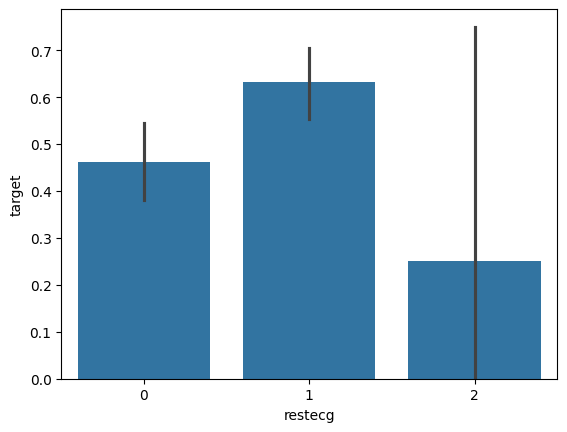

In [39]:
sns.barplot(x=dataset["restecg"], y=y)


##### We realize that people with restecg '1' and '0' are much more likely to have a heart disease than with restecg '2'

### Analysing the 'exang' feature

In [40]:
dataset["exang"].unique()

array([0, 1])

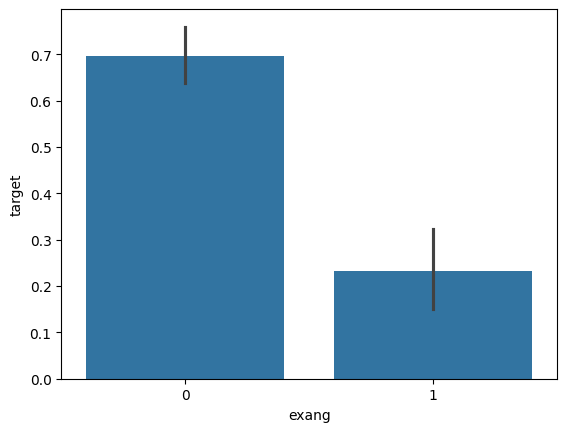

In [41]:
sns.barplot(x=dataset["exang"], y=dataset["target"])
plt.show()



##### People with exang=1 i.e. Exercise induced angina are much less likely to have heart problems

### Analysing the Slope feature

In [42]:
dataset["slope"].unique()

array([0, 2, 1])

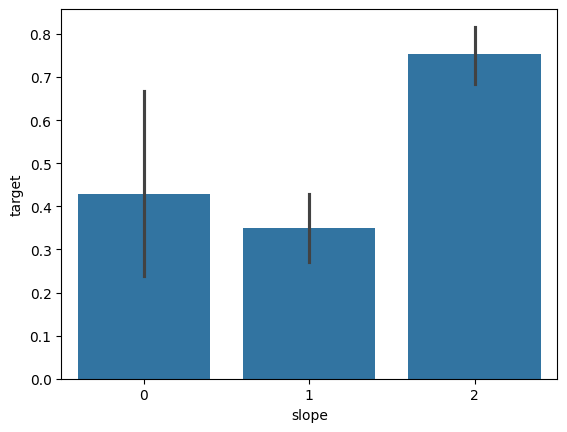

In [43]:
sns.barplot(x=dataset["slope"], y=dataset["target"])
plt.show()


##### We observe, that Slope '2' causes heart pain much more than Slope '0' and '1'

### Analysing the 'ca' feature

In [44]:
#number of major vessels (0-3) colored by flourosopy

In [45]:
dataset["ca"].unique()

array([0, 2, 1, 3, 4])

<Axes: ylabel='count'>

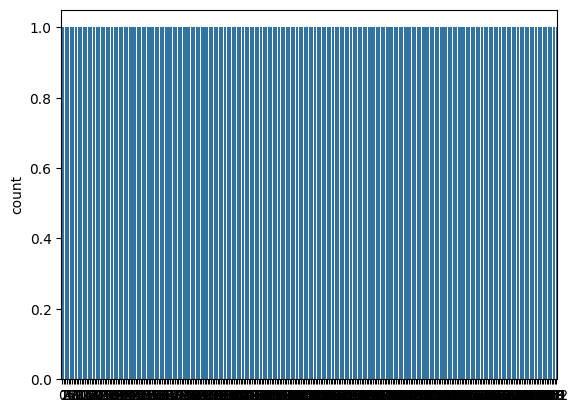

In [46]:
sns.countplot(dataset["ca"])

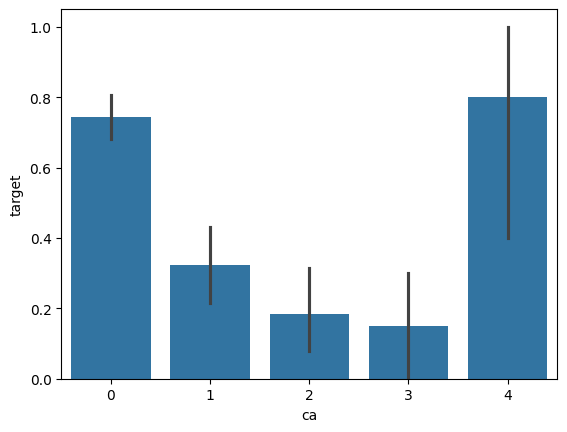

In [47]:
sns.barplot(x=dataset["ca"], y=dataset["target"])
plt.show()


##### ca=4 has astonishingly large number of heart patients

In [48]:
### Analysing the 'thal' feature

In [49]:
dataset["thal"].unique()

array([1, 2, 3, 0])

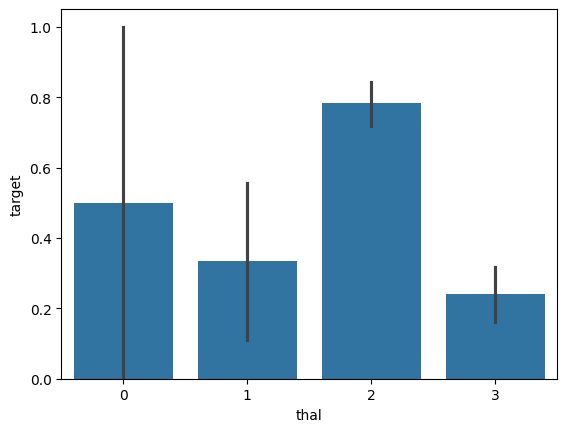

In [50]:
sns.barplot(x=dataset["thal"], y=dataset["target"])
plt.show()


<Axes: xlabel='thal', ylabel='Density'>

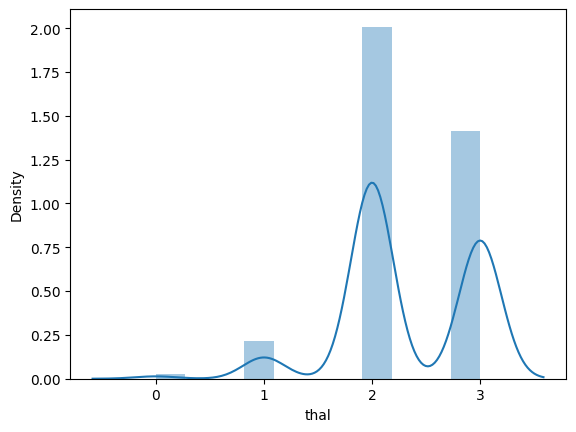

In [51]:
sns.distplot(dataset["thal"])

## IV. Train Test split

In [53]:
from sklearn.model_selection import train_test_split

predictors = dataset.drop("target",axis=1)
target = dataset["target"]

X_train,X_test,Y_train,Y_test = train_test_split(predictors,target,test_size=0.20,random_state=0)

In [54]:
X_train.shape

(242, 13)

In [55]:
X_test.shape

(61, 13)

In [56]:
Y_train.shape

(242,)

In [57]:
Y_test.shape

(61,)

## V. Model Fitting

In [58]:
from sklearn.metrics import accuracy_score

### Logistic Regression

In [59]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,Y_train)

Y_pred_lr = lr.predict(X_test)

In [60]:
Y_pred_lr.shape

(61,)

In [61]:
score_lr = round(accuracy_score(Y_pred_lr,Y_test)*100,2)

print("The accuracy score achieved using Logistic Regression is: "+str(score_lr)+" %")

The accuracy score achieved using Logistic Regression is: 85.25 %


### Naive Bayes

In [62]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train,Y_train)

Y_pred_nb = nb.predict(X_test)

In [63]:
Y_pred_nb.shape

(61,)

In [64]:
score_nb = round(accuracy_score(Y_pred_nb,Y_test)*100,2)

print("The accuracy score achieved using Naive Bayes is: "+str(score_nb)+" %")

The accuracy score achieved using Naive Bayes is: 85.25 %


### SVM

In [65]:
from sklearn import svm

sv = svm.SVC(kernel='linear')

sv.fit(X_train, Y_train)

Y_pred_svm = sv.predict(X_test)

In [66]:
Y_pred_svm.shape

(61,)

In [67]:
score_svm = round(accuracy_score(Y_pred_svm,Y_test)*100,2)

print("The accuracy score achieved using Linear SVM is: "+str(score_svm)+" %")

The accuracy score achieved using Linear SVM is: 81.97 %


### K Nearest Neighbors

In [68]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,Y_train)
Y_pred_knn=knn.predict(X_test)

In [69]:
Y_pred_knn.shape

(61,)

In [70]:
score_knn = round(accuracy_score(Y_pred_knn,Y_test)*100,2)

print("The accuracy score achieved using KNN is: "+str(score_knn)+" %")

The accuracy score achieved using KNN is: 67.21 %


### Decision Tree

In [71]:
from sklearn.tree import DecisionTreeClassifier

max_accuracy = 0


for x in range(200):
    dt = DecisionTreeClassifier(random_state=x)
    dt.fit(X_train,Y_train)
    Y_pred_dt = dt.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_dt,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x
        
#print(max_accuracy)
#print(best_x)


dt = DecisionTreeClassifier(random_state=best_x)
dt.fit(X_train,Y_train)
Y_pred_dt = dt.predict(X_test)

In [72]:
print(Y_pred_dt.shape)

(61,)


In [73]:
score_dt = round(accuracy_score(Y_pred_dt,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_dt)+" %")

The accuracy score achieved using Decision Tree is: 81.97 %


### Random Forest

In [74]:
from sklearn.ensemble import RandomForestClassifier

max_accuracy = 0


for x in range(2000):
    rf = RandomForestClassifier(random_state=x)
    rf.fit(X_train,Y_train)
    Y_pred_rf = rf.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_rf,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x
        
#print(max_accuracy)
#print(best_x)

rf = RandomForestClassifier(random_state=best_x)
rf.fit(X_train,Y_train)
Y_pred_rf = rf.predict(X_test)

In [75]:
Y_pred_rf.shape

(61,)

In [76]:
score_rf = round(accuracy_score(Y_pred_rf,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_rf)+" %")

The accuracy score achieved using Decision Tree is: 90.16 %


### Neural Network

In [79]:
from keras.models import Sequential
from keras.layers import Dense

In [80]:


model = Sequential()
model.add(Dense(11,activation='relu',input_dim=13))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [81]:
model.fit(X_train,Y_train,epochs=300)

Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4587 - loss: 22.8659  
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4587 - loss: 20.1234
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4587 - loss: 17.6706
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4587 - loss: 15.2152
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4587 - loss: 12.9160
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4587 - loss: 10.6772
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4587 - loss: 8.3906
Epoch 8/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4587 - loss: 6.1410
Epoch 9/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4587 - loss: 3.9177
Epoch 10/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4587 - loss: 2.1036
Epoch 11/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5372 - loss: 1.4200
Epoch 12/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5372 - loss: 

In [93]:
Y_pred_nn = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [94]:
Y_pred_nn.shape

(61, 1)

In [95]:
rounded = [round(x[0]) for x in Y_pred_nn]

Y_pred_nn = rounded


 VI. Output final score

In [90]:
score_nn = round(accuracy_score(Y_pred_nn,Y_test)*100,2)

print("The accuracy score achieved using Neural Network is: "+str(score_nn)+" %")

#Note: Accuracy of 85% can be achieved on the test set, by setting epochs=2000, and number of nodes = 11. 

# #%% md



The accuracy score achieved using Neural Network is: 83.61 %


In [86]:
scores = [score_lr,score_nb,score_svm,score_knn,score_dt,score_rf,score_nn]
algorithms = ["Logistic Regression","Naive Bayes","Support Vector Machine","K-Nearest Neighbors","Decision Tree","Random Forest","Neural Network"]    

for i in range(len(algorithms)):
    print("The accuracy score achieved using "+algorithms[i]+" is: "+str(scores[i])+" %")

The accuracy score achieved using Logistic Regression is: 85.25 %
The accuracy score achieved using Naive Bayes is: 85.25 %
The accuracy score achieved using Support Vector Machine is: 81.97 %
The accuracy score achieved using K-Nearest Neighbors is: 67.21 %
The accuracy score achieved using Decision Tree is: 81.97 %
The accuracy score achieved using Random Forest is: 90.16 %
The accuracy score achieved using Neural Network is: 83.61 %


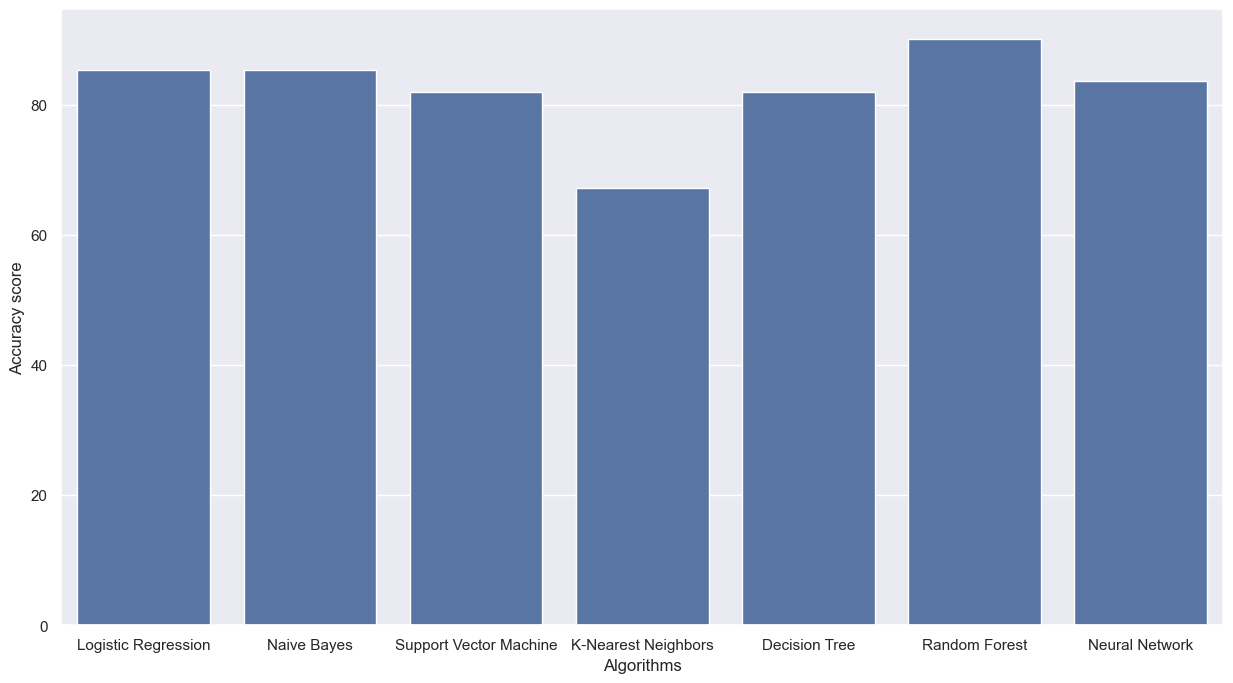

In [87]:
sns.set(rc={'figure.figsize': (15, 8)})
plt.xlabel("Algorithms")
plt.ylabel("Accuracy score")

sns.barplot(x=algorithms, y=scores)
plt.show()


In [88]:
import numpy as np
import pandas as pd


def get_user_input():
    print("\nEnter patient details (examples given):\n")

    age = int(input("Age (example: 52) → Integer: "))
    sex = int(input("Sex (1 = Male, 0 = Female) → Enter 0 or 1: "))
    cp = int(input("Chest Pain Type (0–3) → 0=typical, 1=atypical, 2=non-anginal, 3=asymptomatic: "))
    trestbps = int(input("Resting Blood Pressure in mmHg (example: 130) → Integer: "))
    chol = int(input("Serum Cholesterol in mg/dl (example: 230) → Integer: "))
    fbs = int(input("Fasting Blood Sugar >120 mg/dl (1=True, 0=False) → Enter 0 or 1: "))
    restecg = int(input("Resting ECG (0=normal, 1=ST-T abnormality, 2=LV hypertrophy) → Enter 0–2: "))
    thalach = int(input("Maximum Heart Rate Achieved (example: 150) → Integer: "))
    exang = int(input("Exercise-Induced Angina (1=Yes, 0=No) → Enter 0 or 1: "))
    oldpeak = float(input("Oldpeak (ST depression, example: 1.4) → Decimal: "))
    slope = int(input("Slope of ST Segment (0=up, 1=flat, 2=down) → Enter 0–2: "))
    ca = int(input("Number of Major Vessels (0–3): "))
    thal = int(input("Thalassemia (1=normal, 2=fixed defect, 3=reversible defect) → Enter 1–3: "))

    return [[age, sex, cp, trestbps, chol, fbs, restecg,
             thalach, exang, oldpeak, slope, ca, thal]]



print("\nChoose a prediction model:")
print("1 → Logistic Regression")
print("2 → Naive Bayes")
print("3 → Support Vector Machine (SVM)")
print("4 → K-Nearest Neighbors")
print("5 → Decision Tree")
print("6 → Random Forest")
print("7 → Neural Network (Keras)\n")

choice = int(input("Enter your choice (1–7): "))


model_map = {
    1: lr,       # Logistic Regression
    2: nb,       # Naive Bayes
    3: sv,       # SVM
    4: knn,      # KNN
    5: dt,       # Decision Tree
    6: rf,       # Random Forest
    7: model     # Neural Network (Keras)
}

if choice not in model_map:
    print("❌ Invalid choice! Enter 1–7.")
else:
    selected_model = model_map[choice]
    print("\n✔ You selected:", selected_model)

 
    new_data = get_user_input()

   
    columns = ['age','sex','cp','trestbps','chol','fbs','restecg',
               'thalach','exang','oldpeak','slope','ca','thal']

    new_df = pd.DataFrame(new_data, columns=columns)

   
    prediction = selected_model.predict(new_df)

    print("\n===== FINAL PREDICTION RESULT =====\n")
    if prediction[0] == 1:
        print("🔴 HIGH RISK: Patient likely has HEART DISEASE (Prediction = 1)\n")
    else:
        print("🟢 LOW RISK: Patient does NOT have heart disease (Prediction = 0)\n")



Choose a prediction model:
1 → Logistic Regression
2 → Naive Bayes
3 → Support Vector Machine (SVM)
4 → K-Nearest Neighbors
5 → Decision Tree
6 → Random Forest
7 → Neural Network (Keras)


✔ You selected: <Sequential name=sequential, built=True>

Enter patient details (examples given):

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

===== FINAL PREDICTION RESULT =====

🟢 LOW RISK: Patient does NOT have heart disease (Prediction = 0)



In [89]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(rf, f)  # Change 'model' to 'rf'